In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [8]:
print("Duplicates :", df.duplicated().sum())

Duplicates : 0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

print(df.shape)

(2640, 12)


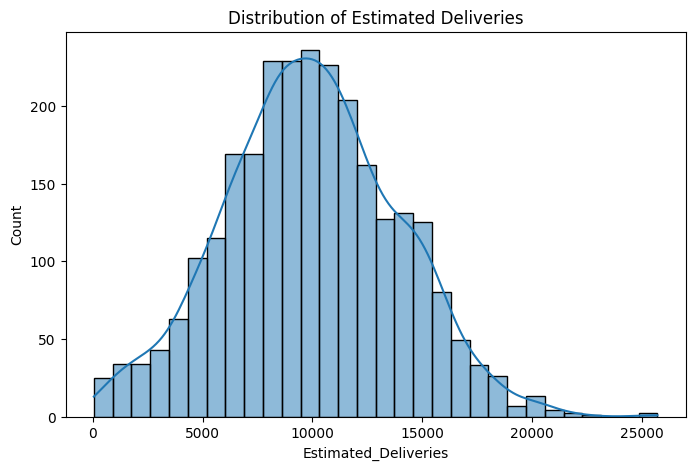

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.show()

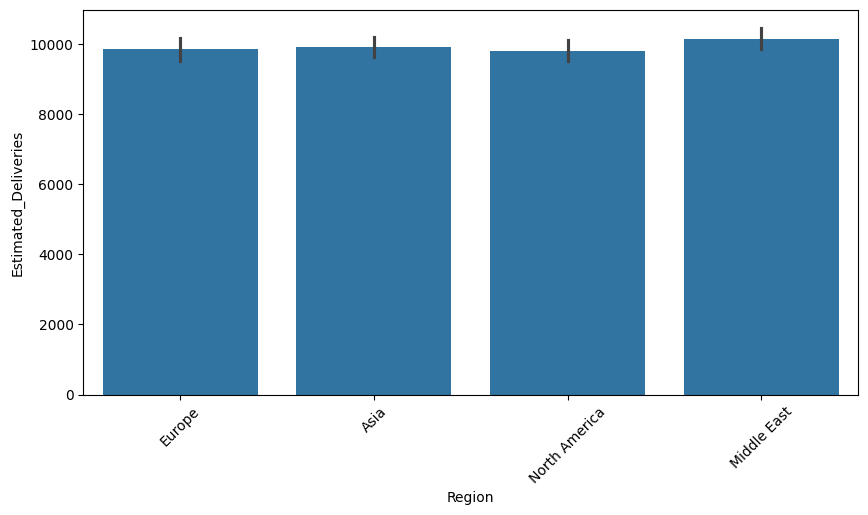

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.show()

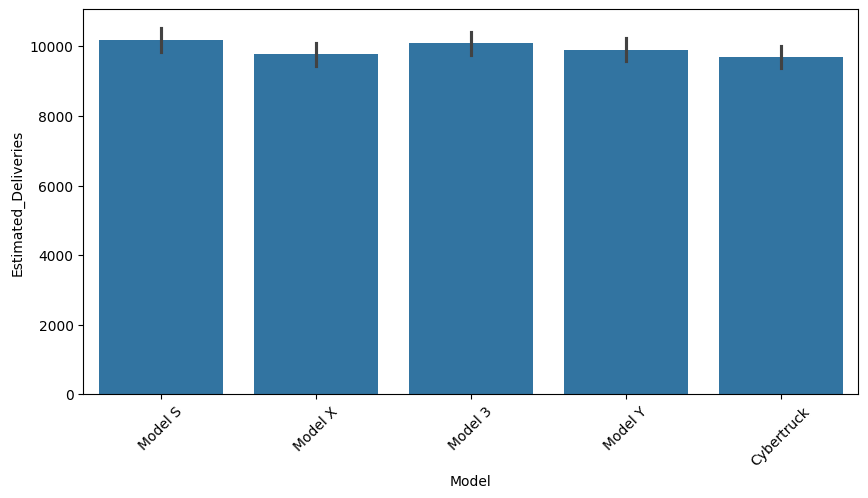

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.show()

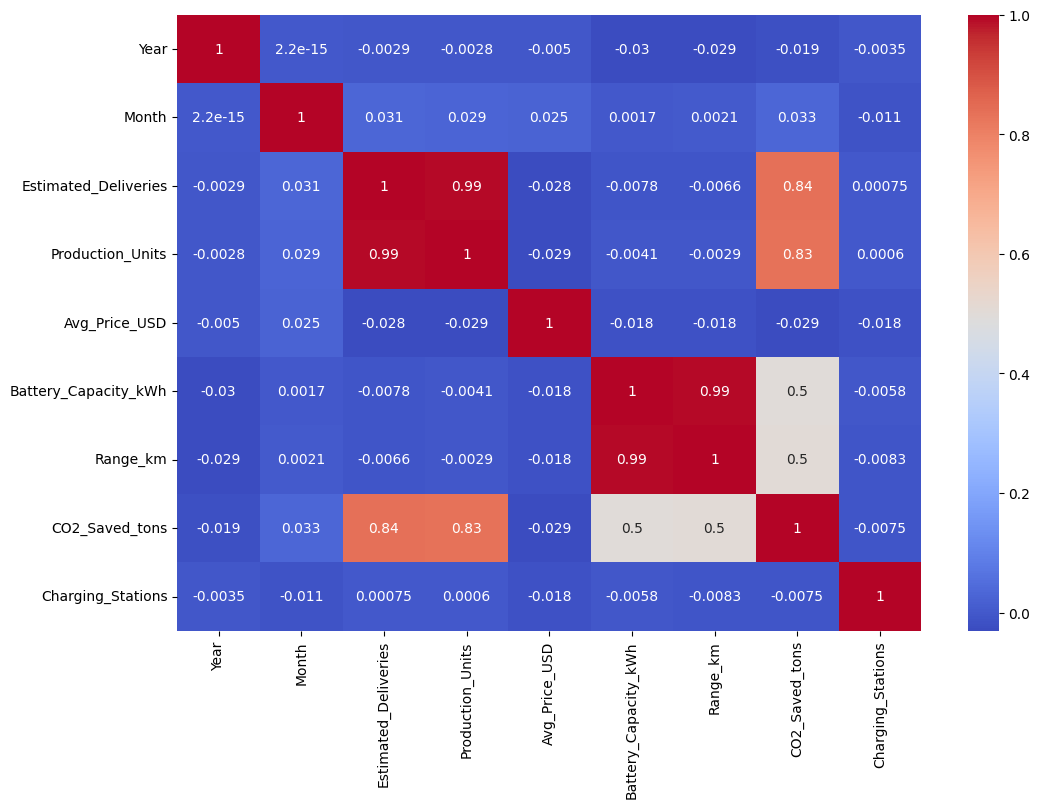

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

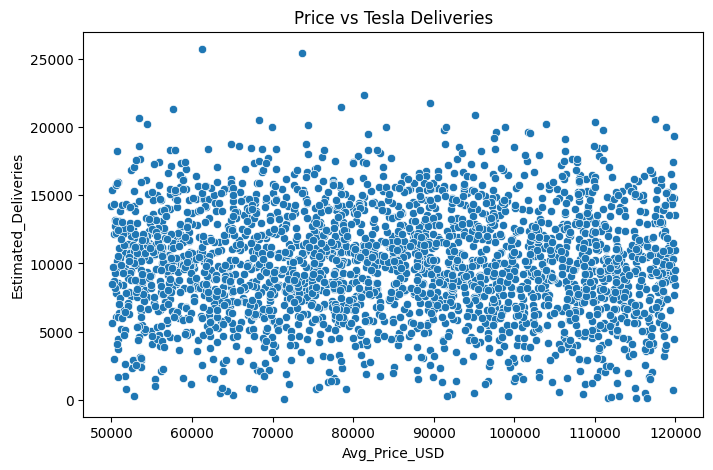

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Price_USD",
    y="Estimated_Deliveries"
)

plt.title(
    "Price vs Tesla Deliveries"
)

plt.show()

In [16]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-" +
    df["Month"].astype(str)
    + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [17]:
df["Quarter"] = df["Date"].dt.quarter

df[["Date","Quarter"]].head()

,Date,Quarter
0,2023-05-01,2
1,2015-02-01,1
2,2019-01-01,1
3,2021-02-01,1
4,2016-12-01,4


In [18]:
df = df.sort_values("Date")

df["Lag_1_Delivery"] = (
    df["Estimated_Deliveries"].shift(1)
)

df["Lag_3_Delivery"] = (
    df["Estimated_Deliveries"].shift(3)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Lag_1_Delivery,Lag_3_Delivery
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,NaN,NaN
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,12446.0,NaN
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,11446.0,NaN
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,8803.0,12446.0
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,6367.0,11446.0


In [19]:
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .mean()
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Lag_1_Delivery,Lag_3_Delivery,Rolling_Mean_3
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,NaN,NaN,NaN
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,12446.0,NaN,NaN
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,11446.0,NaN,10898.333333
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,8803.0,12446.0,8872.000000
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,6367.0,11446.0,7988.333333


In [20]:
df = df.dropna()

df.shape

(2637, 17)

In [21]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

y = df["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2637, 15)
(2637,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2109, 15)
(528, 15)


In [23]:
num_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = X.select_dtypes(
    include="object"
).columns

print(num_cols)
print(cat_cols)

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Lag_1_Delivery', 'Lag_3_Delivery',
       'Rolling_Mean_3'],
      dtype='object')
Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [24]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [25]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [27]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [28]:
lr_pipeline.fit(X_train,y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [29]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    mse = mean_squared_error(y_true,y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true,y_pred)

    print("MAE :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R2 :", round(r2,4))

In [30]:
print("Linear Regression")

evaluate(y_test,y_pred_lr)

Linear Regression
MAE : 312.14
RMSE : 385.67
R2 : 0.9898


In [31]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_pipeline.fit(X_train,y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)

print("Ridge Regression")

evaluate(y_test,y_pred_ridge)

Ridge Regression
MAE : 312.09
RMSE : 385.53
R2 : 0.9898


In [32]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso())
    ]
)

lasso_pipeline.fit(X_train,y_train)

y_pred_lasso = lasso_pipeline.predict(X_test)

print("Lasso Regression")

evaluate(y_test,y_pred_lasso)

Lasso Regression
MAE : 311.71
RMSE : 384.64
R2 : 0.9899


In [33]:
models_result = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "R2 Score":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_lasso)
    ]

})

models_result

,Model,R2 Score
0,Linear Regression,0.989801
1,Ridge,0.989809
2,Lasso,0.989856


In [34]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print(cv_scores)

print("Average Score :", cv_scores.mean())

[0.98980121 0.98997788 0.99013799 0.99040689 0.99099217]
Average Score : 0.9902632300053422


In [35]:
ridge_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

params = {
    "model__alpha":[0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    ridge_pipe,
    params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__alpha': 1}
0.99031226046231


In [36]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

evaluate(y_test,pred)

MAE : 312.09
RMSE : 385.53
R2 : 0.9898


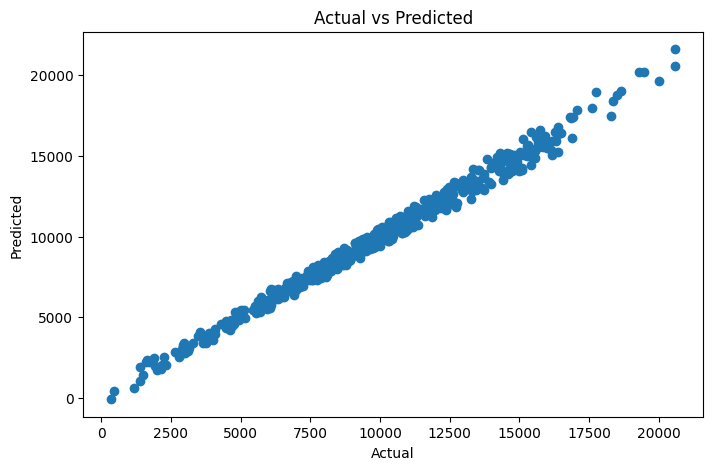

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [38]:
ts = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

ts.head()

Date
2015-01-01    150485
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

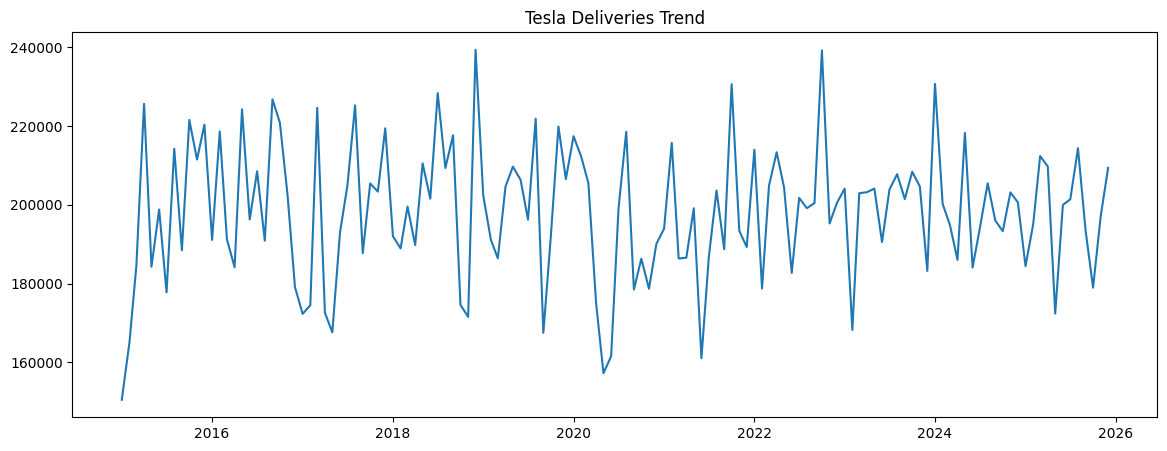

In [39]:
plt.figure(figsize=(14,5))

plt.plot(ts)

plt.title("Tesla Deliveries Trend")

plt.show()

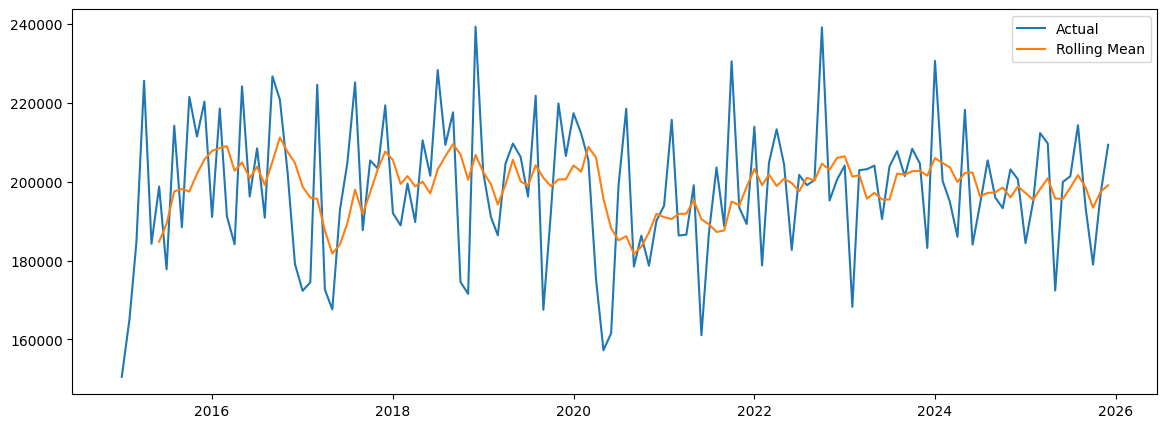

In [40]:
rolling_avg = ts.rolling(6).mean()

plt.figure(figsize=(14,5))

plt.plot(ts,label="Actual")

plt.plot(
    rolling_avg,
    label="Rolling Mean"
)

plt.legend()

plt.show()

In [41]:
forecast_df = ts.reset_index()

forecast_df["Time_Index"] = range(
    len(forecast_df)
)

forecast_df.head()

,Date,Estimated_Deliveries,Time_Index
0,2015-01-01,150485,0
1,2015-02-01,165053,1
2,2015-03-01,184567,2
3,2015-04-01,225623,3
4,2015-05-01,184264,4


In [42]:
X_ts = forecast_df[["Time_Index"]]

y_ts = forecast_df[
    "Estimated_Deliveries"
]

forecast_model = LinearRegression()

forecast_model.fit(X_ts,y_ts)

LinearRegression()

In [43]:
future_index = np.arange(
    len(forecast_df),
    len(forecast_df)+12
).reshape(-1,1)

future_pred = forecast_model.predict(
    future_index
)

future_dates = pd.date_range(
    start=forecast_df["Date"].max(),
    periods=13,
    freq="M"
)[1:]

In [44]:
forecast_result = pd.DataFrame({
    "Future_Date":future_dates,
    "Forecasted_Deliveries":future_pred
})

forecast_result

,Future_Date,Forecasted_Deliveries
0,2026-01-31,198931.949803
1,2026-02-28,198943.012161
2,2026-03-31,198954.074518
3,2026-04-30,198965.136876
4,2026-05-31,198976.199233
5,2026-06-30,198987.261591
6,2026-07-31,198998.323948
7,2026-08-31,199009.386306
8,2026-09-30,199020.448663
9,2026-10-31,199031.511021


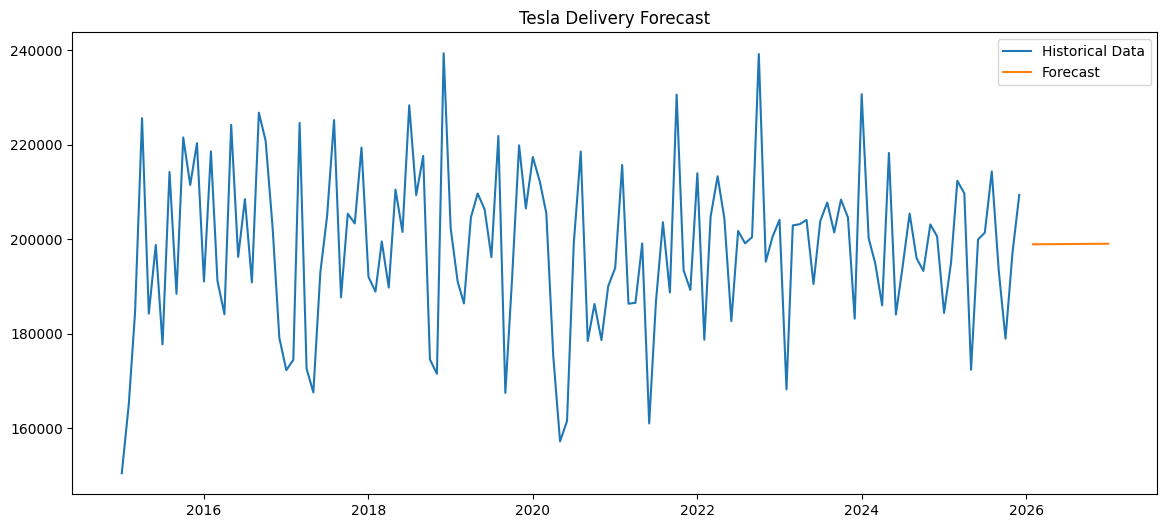

In [45]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df["Date"],
    y_ts,
    label="Historical Data"
)

plt.plot(
    future_dates,
    future_pred,
    label="Forecast"
)

plt.legend()

plt.title(
    "Tesla Delivery Forecast"
)

plt.show()